# Accountability Patterns in AIAAIC

Comparing AIAAIC against the findings of *"From Incidents to Insights: Patterns of Responsibility following AI Harms"* (Hogan et al.), which analyzed 962 incidents from the AIID database. Do similar accounability patterns show up here?

Paper's main claims to check:
- developer = deployer (Big Tech self-operating) → less accounability
- organizational victims get more response than individual users
- anonymous actors (no identifiable deployer) → more legislative mobilization
- deepfakes drive the most societal mobilization

**Caveat:** AIAAIC and AIID code accounability differently. Response and consequence fields are ~75–80% missing in AIAAIC. So everything below is *documented* rates, not real-world rates.

### Setup

Load the cleaned data, match the websites analytical range (2015 onward, keeping undated), and convert the has_consequence / has_response fields to actual booleans.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv('aiaaic_cleaned.csv')
df = df[(df['year'].isna()) | (df['year'] >= 2015)].reset_index(drop=True)
df['has_c'] = (df['has_consequence'].astype(str) == 'True')
df['has_r'] = (df['has_response'].astype(str) == 'True')

n = len(df)
n_c       = int(df['has_c'].sum())
n_r       = int(df['has_r'].sum())
n_both    = int((df['has_c'] & df['has_r']).sum())
n_neither = int(((~df['has_c']) & (~df['has_r'])).sum())

print(f'Total incidents (2015+): {n}')
print(f'  Consequence rate:  {n_c/n*100:5.1f}%  ({n_c})')
print(f'  Response rate:     {n_r/n*100:5.1f}%  ({n_r})')
print(f'  Both:              {n_both/n*100:5.1f}%  ({n_both})')
print(f'  Neither:           {n_neither/n*100:5.1f}%  ({n_neither})')

Total incidents (2015+): 2203
  Consequence rate:   25.1%  (553)
  Response rate:      21.1%  (464)
  Both:                6.2%  (136)
  Neither:            60.0%  (1322)


**Observation:** 
- Out of 2,203 incidents from 2015 on, only 25% have a documented consequence and 21% have a documented response.
- The dominant story is the 60% that have **neither** — three in five incidents fall into a black hole.
- Only 6.2% have both. Consequence and response are largely separate populations in this database.

### Developper—deployer relation

The paper says developer = deployer (Big Tech self-operating) generates fewer formal responses, and anonymous actors (no identifiable deployer) drive most legislative mobilization. Does AIAAIC show the same?

Set up a five-way classification: same entity, diferent entities, unknown developer, unknown deployer, both unknown.

In [2]:
# Multi-coded developer / deployer fields → sets of entities
def to_set(v):
    if pd.isna(v) or not str(v).strip():
        return set()
    return {t.strip() for t in str(v).split(';') if t.strip()}

df['dev_set'] = df['developer'].apply(to_set)
df['dep_set'] = df['deployer'].apply(to_set)

# `same_entity` requires any overlap between the two sets — a multi-coded row that
# lists the same company in both columns counts as same.
def dd_class(row):
    dev, dep = row['dev_set'], row['dep_set']
    if not dev and not dep:  return 'both_unknown'
    if not dev:              return 'dev_unknown'
    if not dep:              return 'dep_unknown'
    if dev & dep:            return 'same_entity'
    return 'different'

df['dd_class'] = df.apply(dd_class, axis=1)
print(df['dd_class'].value_counts())

dd_class
different       724
same_entity     724
dep_unknown     428
dev_unknown     196
both_unknown    131
Name: count, dtype: int64


In [3]:
def rate_table(d, group_col, count_col='aiaaic_id'):
    return (d.groupby(group_col).agg(
        n=(count_col, 'size'),
        consequence_rate=('has_c', lambda x: x.mean() * 100),
        response_rate=('has_r', lambda x: x.mean() * 100),
    ).round(1).sort_values('n', ascending=False))

dd_rates = rate_table(df, 'dd_class')
dd_rates['share_of_total'] = (dd_rates['n'] / len(df) * 100).round(1)
dd_rates

,n,consequence_rate,response_rate,share_of_total
dd_class,,,,
different,724,29.7,20.9,32.9
same_entity,724,25.1,27.5,32.9
dep_unknown,428,20.8,16.4,19.4
dev_unknown,196,20.9,17.3,8.9
both_unknown,131,19.8,7.6,5.9


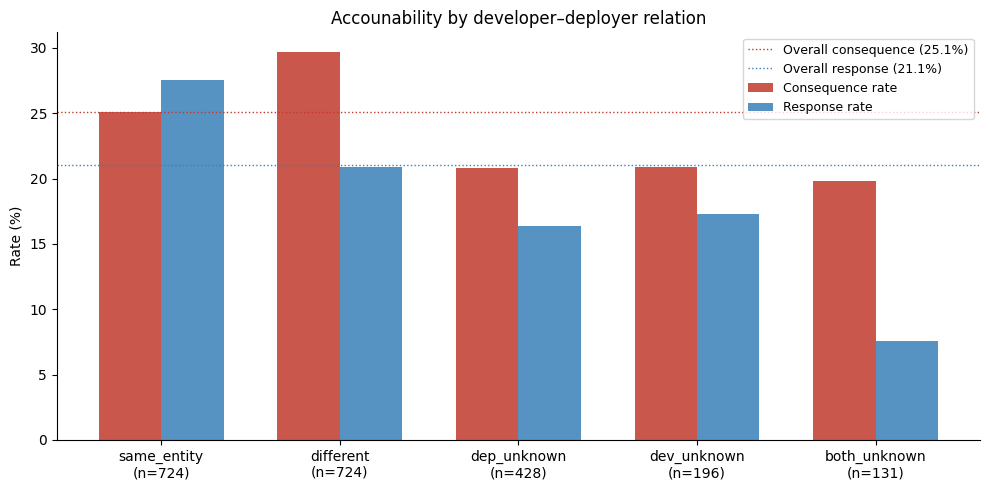

In [4]:
# paired bars per group, plus dotted overall baseline
OVERALL_C = df['has_c'].mean() * 100
OVERALL_R = df['has_r'].mean() * 100

ORDER = ['same_entity', 'different', 'dep_unknown', 'dev_unknown', 'both_unknown']
rates = dd_rates.reindex(ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rates))
w = 0.35
ax.bar(x - w/2, rates['consequence_rate'], w, color='#c0392b', alpha=0.85, label='Consequence rate')
ax.bar(x + w/2, rates['response_rate'],    w, color='#3a80b8', alpha=0.85, label='Response rate')
ax.axhline(OVERALL_C, color='#c0392b', linestyle=':', linewidth=1, label=f'Overall consequence ({OVERALL_C:.1f}%)')
ax.axhline(OVERALL_R, color='#3a80b8', linestyle=':', linewidth=1, label=f'Overall response ({OVERALL_R:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels([f'{l}\n(n={n})' for l, n in zip(rates.index, rates['n'])], fontsize=10)
ax.set_ylabel('Rate (%)')
ax.set_title('Accounability by developer–deployer relation')
ax.spines[['top','right']].set_visible(False)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** 
- I expected `same_entity` to look worse but it actually has the **highest** response rate (27.5%). Opposite of the paper. Maybe AIAAIC volunteer curators just have more access to big tech press statements?
- `both_unknown` has the lowest response rate (7.6%) — this **does** match the paper. No actor to respond means no response gets documented.
- `different` (third-party deployer) has the highest consequence rate (29.7%). When there's a clear party to sue, lawsuits happen.

### No consequence AND no response

For each developer/deployer category, what share of incidents have neither a documented consequence nor a documented response? This is the "fell into a black hole" metric — incidents the database knows about but no accounability of any kind followed.

In [5]:
df['neither'] = (~df['has_c']) & (~df['has_r'])

ORDER = ['same_entity', 'different', 'dev_unknown', 'dep_unknown', 'both_unknown']
LABELS = {
    'same_entity':  'developer = deployer',
    'different':    'developer ≠ deployer',
    'dev_unknown':  'unknown developer',
    'dep_unknown':  'unknown deployer',
    'both_unknown': 'both unknown',
}

total_n       = len(df)
total_neither = int(df['neither'].sum())

rows = []
for cls in ORDER:
    sub = df[df['dd_class'] == cls]
    n_cat     = len(sub)
    n_neither = int(sub['neither'].sum())
    rows.append({
        'category':              LABELS[cls],
        'n_category':            n_cat,
        'n_neither':             n_neither,
        'pct_of_category':       round(n_neither / n_cat * 100, 1),
        'pct_of_total_neither':  round(n_neither / total_neither * 100, 1),
    })
rows.append({
    'category':             'TOTAL',
    'n_category':           total_n,
    'n_neither':            total_neither,
    'pct_of_category':      round(total_neither / total_n * 100, 1),
    'pct_of_total_neither': 100.0,
})

neither_table = pd.DataFrame(rows)
neither_table

,category,n_category,n_neither,pct_of_category,pct_of_total_neither
0,developer = deployer,724,402,55.5,30.4
1,developer ≠ deployer,724,411,56.8,31.1
2,unknown developer,196,130,66.3,9.8
3,unknown deployer,428,279,65.2,21.1
4,both unknown,131,100,76.3,7.6
5,TOTAL,2203,1322,60.0,100.0


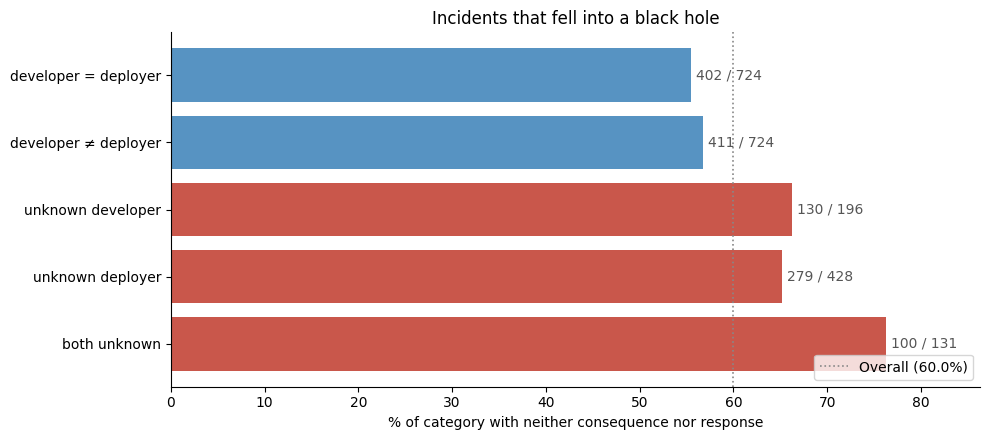

In [6]:
viz = neither_table[neither_table['category'] != 'TOTAL'].copy()
overall_pct = total_neither / total_n * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#c0392b' if p > overall_pct else '#3a80b8' for p in viz['pct_of_category']]
bars = ax.barh(viz['category'], viz['pct_of_category'], color=colors, alpha=0.85)

for bar, nn, nc in zip(bars, viz['n_neither'], viz['n_category']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{nn} / {nc}', va='center', fontsize=10, color='#555')

ax.axvline(overall_pct, color='#888', linestyle=':', linewidth=1.2,
           label=f'Overall ({overall_pct:.1f}%)')
ax.set_xlabel('% of category with neither consequence nor response')
ax.set_title('Incidents that fell into a black hole')
ax.set_xlim(0, max(viz['pct_of_category']) + 10)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Observation:** 
- Cleanly monotonic with attribution loss. 55–57% neither when both actors are known, 65% when one is missing, 76% when both are missing. Three quaters of "both unknown" incidents produced nothing.
- "both unknown" is the only category that visibly differs from the 60% baseline. The two known-actor categories sit within 1.3 points of each other — same vs diferent matters less than known vs unknown.
- The paper's structural finding does replicate here. When no one can be named, no accounability of any kind happens. This is the database-robust signal worth visualizing on the website.

### Legislative mobilization

The paper claims anonymous incidents trigger more legislative mobilization — legislative complaints, legislator letters, legislative proposals. Test against AIAAIC by flagging incidents with these tags.

Caveat: legislative tags are rare (~1.2% overall) so sub-group rates are noisy.

In [7]:
LEGIS_TAGS = {'Legislative complaint', 'Legislator letter', 'Legislative proposal'}

def has_legis(v):
    if pd.isna(v) or not str(v).strip(): return False
    return bool({t.strip() for t in str(v).split(';')} & LEGIS_TAGS)

df['has_legis'] = df['consequence'].apply(has_legis)

df.groupby('dd_class').agg(
    n=('aiaaic_id', 'size'),
    legis_rate=('has_legis', lambda x: x.mean() * 100),
    legis_n=('has_legis', 'sum'),
).round(2).sort_values('legis_rate', ascending=False)

,n,legis_rate,legis_n
dd_class,,,
same_entity,724,1.80,13
different,724,1.10,8
both_unknown,131,0.76,1
dep_unknown,428,0.70,3
dev_unknown,196,0.00,0


**Observation:** 
- In raw rate, `same_entity` actually has the highest legislative rate (1.8%) and `dev_unknown` has zero. Opposite of paper.
- But absolute counts are tiny — 13 legislative incidents in same_entity, 0 in dev_unknown. Probaby just noise.
- AIAAIC's legislative tags are heavy on lawsuits naming big tech defendants. AIID may catch more diffuse mobilization signals (op-eds, advocay campaigns, etc.) we don't have here.
- I'd treat this as inconclusive rather than a real disagreement with the paper.

### Summary: AIAAIC vs paper findings

| Paper claim (from AIID) | AIAAIC observation | Match? |
|---|---|---|
| dev=deployer → fewer responses | dev=deployer has the *highest* response rate (27.5%) | ❌ opposite |
| both unknown → fewer responses | both unknown has the lowest response rate (7.6%) | ✅ matches |
| Organizational victims get more | Individual victims get more consequence (32.7% > 24.6%) | ❌ opposite |
| Anonymous → more legislative mobilization | Sample too small; slightly opposite | ⚠️ inconclusive |
| Deepfakes → societal mobilization | Lower response, lower legislative | ❌ opposite |
| Big Tech accountability gap | Near baseline | ❌ no clear gap |

**The finding that survives the database difference:**

When no actor is identifiable, no accounability of any kind gets recorded. The "both unknown" 7.6% response rate and 76% "neither" rate are the database-robust signals. Everything else mostly reflects encoding differences between AIID and AIAAIC.

For the visualization: don't import the paper's findings wholesale. Anchor on what AIAAIC actually shows — the attribution-loss → accounability-loss pattern, which is the one structural finding both databases agree on.

### Big Tech accountability

Are major AI companies less accountable when operating their own products? Define a big tech list, split by whether the developer is in it and whether dev = deployer.

In [8]:
BIG_TECH = {'OpenAI', 'Google', 'Meta', 'Meta Platforms', 'Facebook', 'Microsoft', 'Amazon',
            'Apple', 'Tesla', 'xAI', 'Anthropic', 'TikTok', 'Nvidia', 'ByteDance'}

def bt_class(row):
    bt_in_dev = bool(row['dev_set'] & BIG_TECH)
    same = row['dd_class'] == 'same_entity'
    different = row['dd_class'] == 'different'
    if bt_in_dev and same:      return 'BigTech self-op'
    if bt_in_dev and different: return 'BigTech dev, other dep'
    if (not bt_in_dev) and same:      return 'Other self-op'
    if (not bt_in_dev) and different: return 'Other dev, other dep'
    return 'unknown / mixed'

df['bt_class'] = df.apply(bt_class, axis=1)
rate_table(df, 'bt_class')

,n,consequence_rate,response_rate
bt_class,,,
unknown / mixed,755,20.7,15.1
"Other dev, other dep",480,27.5,23.3
Other self-op,421,25.7,27.6
BigTech self-op,303,24.4,27.4
"BigTech dev, other dep",244,34.0,16.0


In [9]:
# Per-company breakdown for the top developers
rows = []
for company in sorted(BIG_TECH):
    sub = df[df['dev_set'].apply(lambda s: company in s)]
    if len(sub) < 20:
        continue
    same_share = (sub['dd_class'] == 'same_entity').mean() * 100
    rows.append({
        'company': company,
        'n': len(sub),
        'self_op_share': round(same_share, 1),
        'cons_rate': round(sub['has_c'].mean() * 100, 1),
        'resp_rate': round(sub['has_r'].mean() * 100, 1),
    })
pd.DataFrame(rows).sort_values('n', ascending=False)

,company,n,self_op_share,cons_rate,resp_rate
7,OpenAI,233,30.5,18.9,9.9
4,Google,127,50.4,23.6,30.7
8,Tesla,73,5.5,71.2,16.4
0,Amazon,72,65.3,29.2,15.3
6,Microsoft,68,48.5,22.1,17.6
3,Facebook,66,75.8,24.2,47.0
9,xAI,48,29.2,22.9,20.8
5,Meta Platforms,38,26.3,18.4,13.2
1,Anthropic,23,34.8,17.4,21.7
2,Apple,23,65.2,21.7,17.4


**Observation:** 
- AIAAIC does **not** show a big tech accounability gap like AIID does. Big tech self-operating sits near overall averages on both consequence and response, not noticably lower.
- Per-company variation is wider than the between-category variation. Tesla generates many incidents but with a very diferent profile (litigation-heavy from physical-injury crashes) compared to OpenAI (text-only LLM harms, mostly Reg investigation + Litigation).
- One possibility: AIAAIC seems to code annoucements of consequences ("X has been sued") more liberally than AIID. That inflates the big tech consequence rate without actual enforcement.

### Victim type

The paper claims organizational victims (companies, public institutions) get more accountability than individual users. AIAAIC's schema separates harm by who is harmed: individual vs societal vs environmental.

In [10]:
def victim(row):
    has_i = pd.notna(row['harm_individual']) and str(row['harm_individual']).strip() != ''
    has_s = pd.notna(row['harm_societal'])   and str(row['harm_societal']).strip()   != ''
    if has_i and has_s: return 'both individual & societal'
    if has_i:           return 'individual only'
    if has_s:           return 'societal only'
    return 'no harm coded'

df['victim'] = df.apply(victim, axis=1)
rate_table(df, 'victim').sort_values('consequence_rate', ascending=False)

,n,consequence_rate,response_rate
victim,,,
both individual & societal,84,35.7,15.5
individual only,710,32.7,19.3
societal only,784,24.6,23.2
no harm coded,625,15.7,21.1


**Observation:** 
- In AIAAIC, individual victims actually get **more** documented consequence (32.7%) than societal victims (24.6%). Opposite of paper.
- This probaby reflects AIAAIC's coding bias. Litigation dominates the consequence taxonomy and most lawsuits are individual-injury cases (privacy, IP, personal harm).
- "Both" category is highest (35.7%) but tiny (n=84). Incidents that harm both individuals and society are by definition the most visible ones — selection effect.
- "no harm coded" has the lowest consequence rate (15.7%). Probaby selection effect again: incidents that didn't get fully coded probably lack the documentation that produces consequence tags.

### Deepfake patterns

The paper claims deepfakes drive societal mobilization, precisely because no direct deployer exists. Compare deepfake-flagged incidents against everything else.

In [11]:
df['is_df'] = df['is_deepfake'].astype(str) == 'True'

comparison = pd.DataFrame({
    'group':       ['Deepfake', 'Other'],
    'n':           [df['is_df'].sum(), (~df['is_df']).sum()],
    'cons_rate':   [df[df['is_df']]['has_c'].mean()*100,  df[~df['is_df']]['has_c'].mean()*100],
    'resp_rate':   [df[df['is_df']]['has_r'].mean()*100,  df[~df['is_df']]['has_r'].mean()*100],
    'legis_rate':  [df[df['is_df']]['has_legis'].mean()*100, df[~df['is_df']]['has_legis'].mean()*100],
    'unknown_dev_share': [
        (df[df['is_df']]['dev_set'].apply(len) == 0).mean() * 100,
        (df[~df['is_df']]['dev_set'].apply(len) == 0).mean() * 100,
    ],
}).round(1)
comparison

,group,n,cons_rate,resp_rate,legis_rate,unknown_dev_share
0,Deepfake,203,19.7,9.4,0.5,63.1
1,Other,2000,25.6,22.2,1.2,10.0


**Observation:** 
- Deepfakes have **lower** response rate (9.4% vs 22.2%). Partly matches the paper's powerlessness finding — no clear deployer means no response gets documented.
- But AIAAIC does **not** show deepfakes triggering more legislative mobilization (0.5% vs 1.2%). Contradicts paper. Maybe AIAAIC undercounts legislative reactions (focuses on incident-specific consequences not broader policy reactions). Or the time period covered here doesn't yet show the legislative effect AIID documented.
- Much higher share of deepfake incidents have unknown developers — confirms the structural observation that deepfakes lack attribution.

### Accountability by technology type

Deepfakes look like a black hole — let's see if other tech categories show similar structural patterns. The `technology` field is multi-coded (one incident can be `Generative AI; Machine learning`) so I use the `is_*` booleans that `clean.py` produced. Buckets overlap by design, so rates per tech are conditional ("of incidents tagged X, what fraction have a consequence") not a partition of the total.

In [12]:
TECH_COLS = {
    'is_generative_ai':        'Generative AI',
    'is_large_language_model': 'Large language model',
    'is_facial_recognition':   'Facial recognition',
    'is_deepfake':             'Deepfake',
    'is_machine_learning':     'Machine learning',
    'is_computer_vision':      'Computer vision',
    'is_self_driving_system':  'Self-driving',
    'is_agentic_ai':           'Agentic AI',
}

rows = []
for col, name in TECH_COLS.items():
    sub = df[df[col].astype(str) == 'True']
    if len(sub) < 20:
        continue
    rows.append({
        'tech':       name,
        'n':          len(sub),
        'cons_rate':  round(sub['has_c'].mean() * 100, 1),
        'resp_rate':  round(sub['has_r'].mean() * 100, 1),
        'neither':    round(((~sub['has_c']) & (~sub['has_r'])).mean() * 100, 1),
    })
tech_rates = pd.DataFrame(rows).sort_values('n', ascending=False).reset_index(drop=True)
tech_rates

,tech,n,cons_rate,resp_rate,neither
0,Generative AI,541,21.3,14.6,66.4
1,Machine learning,524,20.4,21.0,63.4
2,Facial recognition,284,30.6,26.4,51.4
3,Deepfake,203,19.7,9.4,74.4
4,Computer vision,197,25.4,25.9,54.8
5,Self-driving,56,50.0,25.0,33.9
6,Large language model,33,9.1,39.4,57.6
7,Agentic AI,23,17.4,43.5,43.5


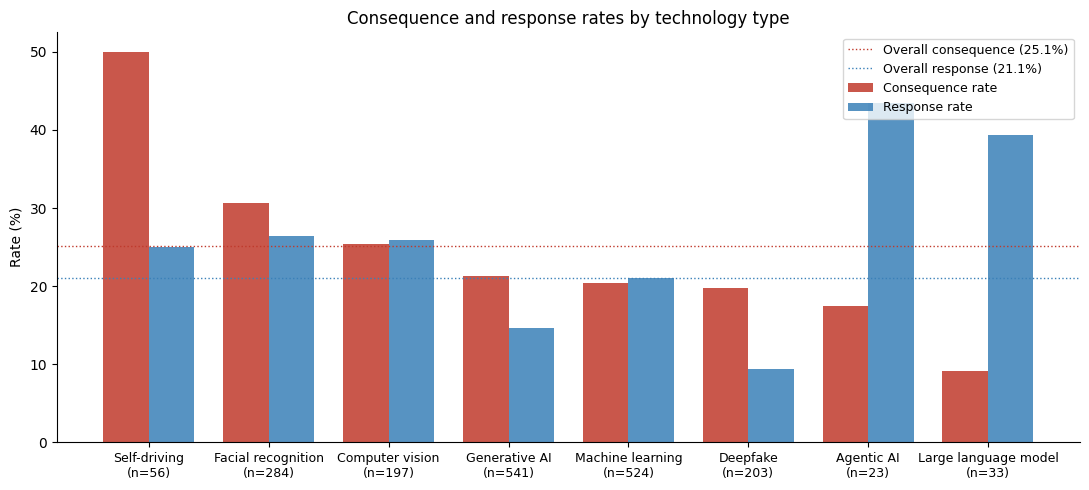

In [13]:
# Sort by consequence rate to surface the gradient
order = tech_rates.sort_values('cons_rate', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(order))
w = 0.38
ax.bar(x - w/2, order['cons_rate'], w, color='#c0392b', alpha=0.85, label='Consequence rate')
ax.bar(x + w/2, order['resp_rate'], w, color='#3a80b8', alpha=0.85, label='Response rate')
ax.axhline(OVERALL_C, color='#c0392b', linestyle=':', linewidth=1, label=f'Overall consequence ({OVERALL_C:.1f}%)')
ax.axhline(OVERALL_R, color='#3a80b8', linestyle=':', linewidth=1, label=f'Overall response ({OVERALL_R:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels([f'{t}\n(n={n})' for t, n in zip(order['tech'], order['n'])], fontsize=9)
ax.set_ylabel('Rate (%)')
ax.set_title('Consequence and response rates by technology type')
ax.spines[['top','right']].set_visible(False)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

**Observation:**
- **Four very different profiles emerge.**
  - *Self-driving* — high consequence (50%), modest response (25%). Physical-injury harms become lawsuits; the response field probably under-counts because automakers go through legal channels, not press statements.
  - *Facial recognition* — above baseline on both (30.6% / 26.4%). Existing regulatory regimes (GDPR, BIPA, EU AI Act) give regulators a hook *and* force vendors to respond publicly.
  - *Large language models* — flipped profile (9% consequence, 39% response). Talk is cheap and LLM harms (hallucinations, bias) are hard to attach a legal cause of action to. Companies issue statements but rarely face enforceable consequence.
  - *Deepfakes* — lowest response (9.4%), 74% neither. The black-hole pattern from the previous section, now in context: it's not just lower than baseline, it's the *only* major category where response drops into single digits.
- Generative AI overall (n=541) sits near baseline because it's a mix — strip out LLM-tagged incidents and you'd see the GenAI rate move closer to baseline.
- **Lesson:** the technology shapes *which kind* of accountability gets recorded. Physical-injury tech → litigation; regulated tech → both; conversational tech → statements; anonymous tech → neither. Looking only at one rate (consequence *or* response) misses this dimension.

### Big Tech × technology

The earlier per-company table gave a single rate per company, which collapses the tech mix. But Tesla's incidents are mostly self-driving and OpenAI's are mostly generative — those baselines are already very different. Better question: when *the same* big tech firm shows up in different tech buckets, do they get treated differently?

Build a (company × tech) grid showing n, consequence rate, and response rate for each cell where the company has at least 5 incidents in that tech.

In [14]:
# Restrict to big tech firms with ≥20 incidents total (per the earlier per-company table)
FOCUS_COMPANIES = ['OpenAI','Google','Tesla','Amazon','Microsoft','Facebook',
                   'xAI','Meta Platforms','Anthropic','Apple']
MIN_CELL = 5  # minimum n in a (company, tech) cell to report rates

TECH_ORDER = list(TECH_COLS.values())  # consistent column ordering

# Long-form table: one row per (company, tech) cell with n ≥ MIN_CELL
records = []
for company in FOCUS_COMPANIES:
    co_mask = df['dev_set'].apply(lambda s: company in s)
    co_df = df[co_mask]
    for col, tech_name in TECH_COLS.items():
        cell = co_df[co_df[col].astype(str) == 'True']
        if len(cell) < MIN_CELL:
            continue
        records.append({
            'company': company,
            'tech': tech_name,
            'n': len(cell),
            'cons_rate': round(cell['has_c'].mean() * 100, 1),
            'resp_rate': round(cell['has_r'].mean() * 100, 1),
        })
grid = pd.DataFrame(records)
grid.sort_values(['company', 'n'], ascending=[True, False])

,company,tech,n,cons_rate,resp_rate
10,Amazon,Machine learning,18,22.2,5.6
11,Amazon,Computer vision,11,45.5,9.1
8,Amazon,Generative AI,7,0.0,42.9
9,Amazon,Facial recognition,5,40.0,20.0
21,Anthropic,Generative AI,18,22.2,16.7
22,Anthropic,Agentic AI,5,0.0,60.0
23,Apple,Generative AI,6,16.7,0.0
24,Apple,Facial recognition,6,0.0,16.7
16,Facebook,Machine learning,24,12.5,54.2
15,Facebook,Facial recognition,7,57.1,42.9


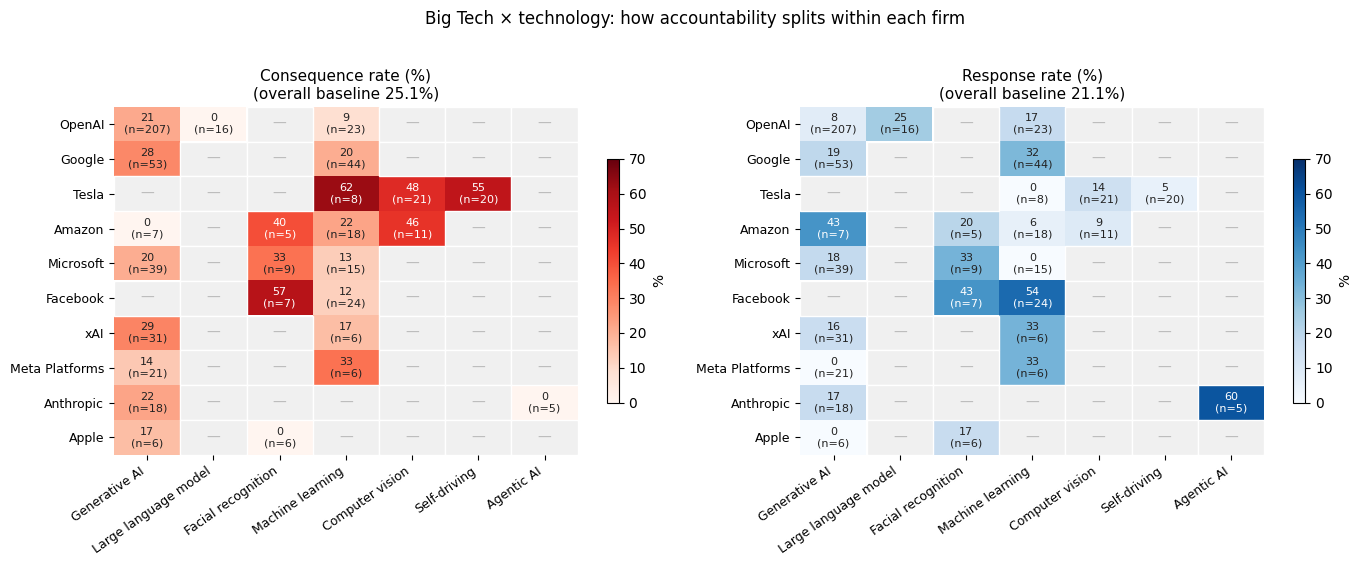

In [15]:
# Dual heatmap: consequence on the left, response on the right.
# Rows = companies (kept in FOCUS_COMPANIES order so eye can scan down).
# Columns = tech buckets (only ones that appear for any company, in TECH_ORDER).
present_tech = [t for t in TECH_ORDER if t in set(grid['tech'])]

def pivot_for(metric):
    return grid.pivot(index='company', columns='tech', values=metric) \
               .reindex(index=FOCUS_COMPANIES, columns=present_tech)

cons = pivot_for('cons_rate')
resp = pivot_for('resp_rate')
ns   = pivot_for('n')

def draw_heat(ax, mat, cmap, title, baseline):
    arr = mat.values
    im = ax.imshow(arr, cmap=cmap, vmin=0, vmax=70, aspect='auto')
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index, fontsize=9)
    # Annotate each cell with "rate% (n=…)"; grey out missing cells
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            v = arr[i, j]
            if np.isnan(v):
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                            facecolor='#f0f0f0', edgecolor='white'))
                ax.text(j, i, '—', ha='center', va='center', color='#bbb', fontsize=10)
            else:
                txt_color = 'white' if v > 35 else '#222'
                ax.text(j, i, f'{v:.0f}\n(n={int(ns.values[i,j])})',
                        ha='center', va='center', color=txt_color, fontsize=8)
    ax.set_title(f'{title}\n(overall baseline {baseline:.1f}%)', fontsize=11)
    ax.spines[:].set_visible(False)
    return im

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
im1 = draw_heat(axes[0], cons, 'Reds',  'Consequence rate (%)', OVERALL_C)
im2 = draw_heat(axes[1], resp, 'Blues', 'Response rate (%)',    OVERALL_R)
fig.colorbar(im1, ax=axes[0], shrink=0.7, label='%')
fig.colorbar(im2, ax=axes[1], shrink=0.7, label='%')
plt.suptitle('Big Tech × technology: how accountability splits within each firm', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

**Observation:**

Reading the heatmaps row-by-row, every big tech firm has *internal variation* — accountability is split across their own product lines.

- **Tesla** is the litigation outlier. ML/CV/Self-driving all sit at 48–62% consequence (vs 25% baseline), but response is 0–14%. Physical-injury crashes go straight to court; Tesla rarely makes a public response that gets coded.
- **OpenAI** has the inverse pattern for its main product line. Generative AI: 21% consequence (near baseline), but only 8% response — for the tech that defines them, OpenAI is *less* publicly responsive than the AIAAIC average. Curiously, their small LLM-tagged subset (n=16) shows 0% consequence, 25% response — exactly the LLM signature from the previous section.
- **Facebook** is the response outlier. 47% response overall, driven by ML (54%) and FacialRec (43%). Facebook talks. But the consequence rates are low (12% ML), so talking ≠ being held accountable.
- **Google** sits closest to baseline across the board — possibly because their incident portfolio is the most diverse (search ranking, ads, GenAI, ML, all mixed), which dilutes any single pattern.
- **Anthropic + Agentic AI** is the most extreme tile (n=5, 60% response, 0% consequence) — too small to read as a real signal, but worth flagging as the agentic-AI early signal: lots of statements, no enforcement mechanism yet.
- **Microsoft + ML** stands out the other way: 0% response rate (n=15). They issue plenty of statements about generative AI (their main product line) but say almost nothing about traditional ML incidents.

**Lesson:** "is this company accountable?" is the wrong question — the company × technology cell is where the variation lives. A firm can be heavily sued in one product line (Tesla / self-driving) and silently absorbed in another (Tesla / ML). Aggregating per-company averages out exactly the variation we care about.

**Caveat:** these are small cells (most n=5–50). Differences of 10–20 percentage points are easily within sampling noise. Treat this as hypothesis generation for the visualization, not statistical claims.

### Accountability over time

The `explore.ipynb` timeline chart paired incident counts with a single accountability rate. Here I want a finer view: both rates plotted simultaneously and each year's volume split across the four accountability quadrants (both / consequence only / response only / neither).

The construction is the natural 2×2 from earlier — `has_consequence × has_response` — applied per year. The two lines are derived from the same buckets: `consequence rate = both + cons_only`, `response rate = both + resp_only`. So the lines and the bars are showing the same underlying counts in two complementary ways: bars expose the *volume* shifting between buckets, lines expose the *rates* without volume distortion.

**Caveat:** AIAAIC's README flags reporting lag — recent incidents haven't had time to develop documented response or consequence yet. Expect 2025–26 rates to dip partly for that reason, not because companies suddenly stopped being held accountable.

In [16]:
# Year × quadrant breakdown. Drop undated rows here (the rate-only earlier
# analyses could keep them, but a timeline can't place them).
dated = df.dropna(subset=['year']).copy()
dated['year'] = dated['year'].astype(int)

yearly = pd.DataFrame({
    'both':      ( dated['has_c'] &  dated['has_r']).groupby(dated['year']).sum(),
    'cons_only': ( dated['has_c'] & ~dated['has_r']).groupby(dated['year']).sum(),
    'resp_only': (~dated['has_c'] &  dated['has_r']).groupby(dated['year']).sum(),
    'neither':   (~dated['has_c'] & ~dated['has_r']).groupby(dated['year']).sum(),
}).fillna(0).astype(int)
yearly['total']     = yearly[['both','cons_only','resp_only','neither']].sum(axis=1)
yearly['cons_rate'] = (yearly['both'] + yearly['cons_only']) / yearly['total'] * 100
yearly['resp_rate'] = (yearly['both'] + yearly['resp_only']) / yearly['total'] * 100
yearly.round(1)

,both,cons_only,resp_only,neither,total,cons_rate,resp_rate
year,,,,,,,
2015,6,5,3,6,20,55.0,45.0
2016,9,7,14,14,44,36.4,52.3
2017,7,7,20,32,66,21.2,40.9
2018,8,13,18,40,79,26.6,32.9
2019,19,23,21,59,122,34.4,32.8
2020,14,46,36,120,216,27.8,23.1
2021,23,47,32,146,248,28.2,22.2
2022,4,40,20,92,156,28.2,15.4
2023,12,76,57,228,373,23.6,18.5


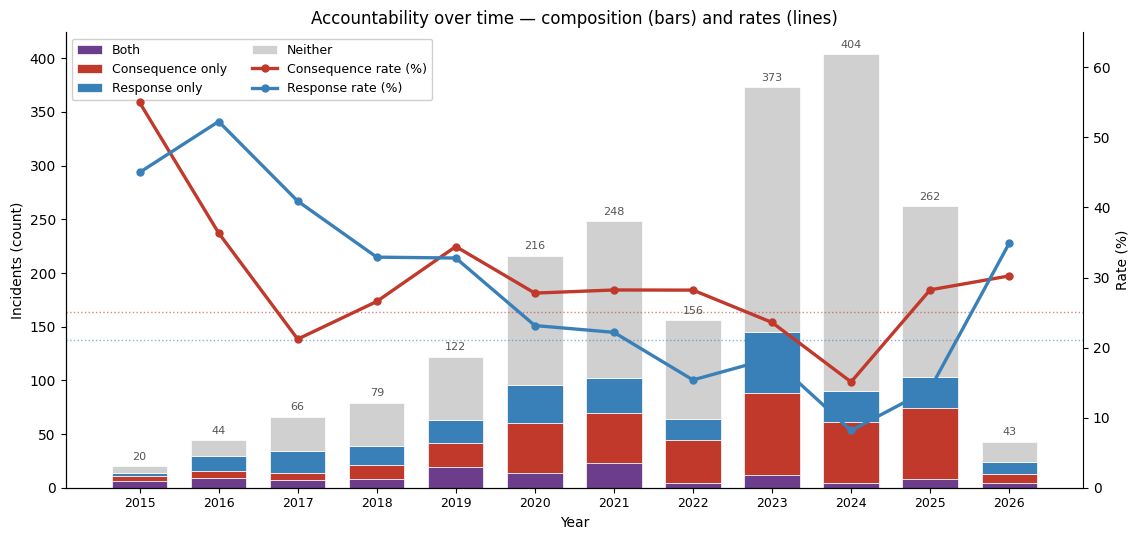

In [17]:
QUAD_COLORS = {
    'both':      '#6b3d8a',  # purple (consequence + response)
    'cons_only': '#c0392b',  # red (matches consequence elsewhere)
    'resp_only': '#3a80b8',  # blue (matches response elsewhere)
    'neither':   '#d0d0d0',  # grey — the black hole
}
QUAD_LABELS = {
    'both':      'Both',
    'cons_only': 'Consequence only',
    'resp_only': 'Response only',
    'neither':   'Neither',
}

fig, ax_bar = plt.subplots(figsize=(11.5, 5.5))

# --- left axis: stacked bars (counts) ---
years = yearly.index
bottoms = np.zeros(len(years))
for key in ['both', 'cons_only', 'resp_only', 'neither']:
    vals = yearly[key].values
    ax_bar.bar(years, vals, bottom=bottoms, width=0.7,
               color=QUAD_COLORS[key], label=QUAD_LABELS[key],
               edgecolor='white', linewidth=0.5)
    bottoms += vals

# Annotate total above each bar
for y, t in zip(years, yearly['total']):
    ax_bar.text(y, t + max(yearly['total']) * 0.015, str(int(t)),
                ha='center', fontsize=8, color='#555')

ax_bar.set_xlabel('Year')
ax_bar.set_ylabel('Incidents (count)')
ax_bar.set_xticks(years)
ax_bar.set_xticklabels(years, rotation=0, fontsize=9)
ax_bar.spines[['top','right']].set_visible(False)

# --- right axis: rate lines (%) ---
ax_line = ax_bar.twinx()
ax_line.plot(years, yearly['cons_rate'], color='#c0392b', lw=2.4,
             marker='o', ms=5, label='Consequence rate (%)', zorder=5)
ax_line.plot(years, yearly['resp_rate'], color='#3a80b8', lw=2.4,
             marker='o', ms=5, label='Response rate (%)', zorder=5)
ax_line.axhline(OVERALL_C, color='#c0392b', linestyle=':', linewidth=1, alpha=0.6)
ax_line.axhline(OVERALL_R, color='#3a80b8', linestyle=':', linewidth=1, alpha=0.6)
ax_line.set_ylabel('Rate (%)')
ax_line.set_ylim(0, max(yearly[['cons_rate','resp_rate']].max().max() + 10, 60))
ax_line.spines[['top']].set_visible(False)

# Merge legends from both axes
h1, l1 = ax_bar.get_legend_handles_labels()
h2, l2 = ax_line.get_legend_handles_labels()
ax_bar.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=9, ncol=2, framealpha=0.95)

ax_bar.set_title('Accountability over time — composition (bars) and rates (lines)')
plt.tight_layout()
plt.show()

**Observation:**

The chart tells a story in three acts.

- **2015–2018 — small-sample noise.** With only 20–80 incidents per year, both rates swing wildly (response rate is 52% in 2016, 33% by 2018). The curators were tracking a handful of high-profile cases each year and most had a documented outcome. Ignore the absolute levels here.
- **2019–2023 — stable equilibrium.** Both rates settle into the 20–35% band and roughly track each other. The "neither" grey band grows from ~48% to ~61% of each bar, but it grows because volume grows faster than consequence/response coverage can keep up — not because rates collapsed.
- **2024 — the GenAI shock.** Total incidents nearly double (248 → 404), and both rates fall off a cliff at the same time: consequence drops from 28% to 15%, response from 22% to 8%. The grey "neither" band swells to 78% of the bar — three quarters of 2024 incidents fell into the black hole. Then 2025 partially rebounds (cons back to 28%, resp 14%), which is consistent with the *2024 dip being driven by reporting lag plus a one-time volume shock* rather than a permanent regime change.

**The two lines crossing matters.** From 2016–2018 the blue response line sat *above* the red consequence line — companies were issuing statements about incidents that had no legal teeth yet. From 2019 onward the red line moves above the blue: enforcement (lawsuits, regulatory action) consistently outpaces public response. Whatever happened around 2019 (GDPR maturity? AIID-era press attention?) flipped which side of accountability dominates.

**The grey band is the real headline.** Even at the rates' high point in 2015, 30% of incidents had neither consequence nor response. By 2024 that's 78%. The visualization on the website should foreground this — the long-term trajectory is *not* incidents getting more accountable, it's the documented-accountability share getting overwhelmed by incident volume.

**Caveat (again):** 2025 is partially complete and 2026 is mostly partial. Lag means recent rates are floors, not point estimates. A re-pull in 12 months would push 2024–25 rates upward.